# Кредитный скоринг на данных кредитных историй
https://www.kaggle.com/competitions/alfa-bank-pd-credit-history/overview  
**Проект еще в разработке!!!**  
> **Этот проектик можно рассматривать как изучение конкретной задачи в дс/мл** _(я учусь только такое решать еще)_.  
> Очень важно, то что я подгрузил сразу весь датасет в один датафрейм, что требует большое количество оперативной памяти, поэтому если кто-то это будет запускать, убедитесь, что у вас оно запуститься.
## Задача
В этом соревновании участникам предлагается решить задачу кредитного скоринга клиентов Альфа-Банка, используя только данные кредитных историй.
## Данные

Датасет соревнования устроен таким образом, что кредиты для тренировочной выборки взяты за период в М месяцев, а кредиты для тестовой выборки взяты за последующие K месяцев.

Каждая запись кредитной истории содержит самую разнообразную информацию о прошлом кредите клиента, например, сумму, отношение клиента к кредиту, дату открытия и закрытия, информацию о просрочках по платежам и др. Все публикуемые данные тщательно анонимизированы.

Целевая переменная – бинарная величина, принимающая значения 0 и 1, где 1 соответствует дефолту клиента по кредиту.

Подробное описание файлов и полей датасета соревнования участники могут найти во вкладке Data.
Проверка решений

**Метрика соревнования – ROC AUC.**

## 0. Импорты

In [ ]:
import warnings
import gc
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

from optbinning.binning import BinningProcess, OptimalBinning
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from catboost import CatBoostClassifier, cv, Pool
from scipy.stats import randint, uniform

warnings.filterwarnings("ignore", category=FutureWarning)

## 1. Подготовка данных
Грубо говоря здесь нужно отделять данные и определять дефолт, но это за меня сделано уже.  
Вкратце как оно обычно проиходит.
- **Определение дефолта (Target):** Задается строгий критерий невозврата. Обычно это непрерывная просрочка 90+ дней (DPD 90+) в рамках заданного окна наблюдения (например, первые 12 месяцев жизни кредита).
- **Маркировка выборки:**
    - 1 (Bad) — клиент допустил просрочку 90+ дней.
    - 0 (Good) — клиент платил исправно весь год.
    - Исключение (Indeterminate) — клиенты с мелкой просрочкой (15–30 дней). Они удаляются из выборки, чтобы модель обучалась на контрастных примерах
- **Временной сплит (Sampling):** Данные делятся по дате выдачи кредита:
    - Train / Validation (70/30): Исторический пласт (например, январь — октябрь 2024 г.) для обучения и настройки.
    - Out-of-Time / OOT (Тест): Более поздний закрытый период (ноябрь — декабрь 2024 г.) для симуляции работы модели в реальных условиях.

In [2]:
NTRAINFILES = 12

files = [f"train_data/train_data_{i}.pq" for i in range(NTRAINFILES)]
arrow_table_train = pq.read_table(files)
X = arrow_table_train.to_pandas()

In [3]:
print(f"X_train shape: {X.shape}")
print(X.info())
print(X.isnull().sum())
print(f"Null count: {X.isnull().sum().sum()}")

X_train shape: (26162717, 61)
<class 'pandas.DataFrame'>
RangeIndex: 26162717 entries, 0 to 26162716
Data columns (total 61 columns):
 #   Column                         Dtype
---  ------                         -----
 0   id                             int64
 1   rn                             int64
 2   pre_since_opened               int64
 3   pre_since_confirmed            int64
 4   pre_pterm                      int64
 5   pre_fterm                      int64
 6   pre_till_pclose                int64
 7   pre_till_fclose                int64
 8   pre_loans_credit_limit         int64
 9   pre_loans_next_pay_summ        int64
 10  pre_loans_outstanding          int64
 11  pre_loans_total_overdue        int64
 12  pre_loans_max_overdue_sum      int64
 13  pre_loans_credit_cost_rate     int64
 14  pre_loans5                     int64
 15  pre_loans530                   int64
 16  pre_loans3060                  int64
 17  pre_loans6090                  int64
 18  pre_loans90          

In [4]:
NTESTFILES = 2

files = [f"test_data/test_data_{i}.pq" for i in range(NTESTFILES)]
arrow_table_test = pq.read_table(files)
X_test = arrow_table_test.to_pandas()

In [5]:
print(f"X_test shape: {X_test.shape}")
print(X_test.info())
print(X_test.isnull().sum())
print(f"Null count: {X_test.isnull().sum().sum()}")

X_test shape: (4724601, 61)
<class 'pandas.DataFrame'>
RangeIndex: 4724601 entries, 0 to 4724600
Data columns (total 61 columns):
 #   Column                         Dtype
---  ------                         -----
 0   id                             int64
 1   rn                             int64
 2   pre_since_opened               int64
 3   pre_since_confirmed            int64
 4   pre_pterm                      int64
 5   pre_fterm                      int64
 6   pre_till_pclose                int64
 7   pre_till_fclose                int64
 8   pre_loans_credit_limit         int64
 9   pre_loans_next_pay_summ        int64
 10  pre_loans_outstanding          int64
 11  pre_loans_total_overdue        int64
 12  pre_loans_max_overdue_sum      int64
 13  pre_loans_credit_cost_rate     int64
 14  pre_loans5                     int64
 15  pre_loans530                   int64
 16  pre_loans3060                  int64
 17  pre_loans6090                  int64
 18  pre_loans90              

In [6]:
y_train_not_extended = pd.read_csv("train_target.csv")

In [7]:
print(f"y_train shape: {y_train_not_extended.shape}")
print(y_train_not_extended.info())

y_train shape: (3000000, 2)
<class 'pandas.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 2 columns):
 #   Column  Dtype
---  ------  -----
 0   id      int64
 1   flag    int64
dtypes: int64(2)
memory usage: 45.8 MB
None


In [8]:
y_test_not_extended = pd.read_csv("test_target.csv")

In [9]:
print(f"y_test shape: {y_test_not_extended.shape}")
print(y_test_not_extended.info())

y_test shape: (500000, 1)
<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 1 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   id      500000 non-null  int64
dtypes: int64(1)
memory usage: 3.8 MB
None


In [10]:
y_train_dict = y_train_not_extended.set_index('id')['flag']
y_train_series = X['id'].map(y_train_dict)
y = y_train_series.to_frame(name='flag')
print(y.shape)

(26162717, 1)


In [11]:
X.drop(columns=["id", "rn"], inplace=True)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

## 2. Трансформация признаков (биннинг, WoE)
На этом этапе непрерывные числа и текстовые категории переводятся на универсальный язык рисков — коэффициенты WoE.
- **Fine Binning (Первичная нарезка):** Каждый числовой признак делится на 10–20 мелких интервалов (квантилей).
- **Coarse Binning (Бизнес-укрупнение):** Смежные интервалы склеиваются алгоритмом оптимизации (например, MILP в библиотеке optbinning) с учетом жестких правил:  
    - Объем каждого получившегося бина — **не менее 5%** от всей выборки.
    - В каждом бине есть хотя бы один дефолт (нет дефолтов — будет деление на ноль).
    - **Монотонность тренда:** Доля дефолтов (Bad Rate) от бина к бину должна строго расти или строго падать (для исключений вроде U-образного риска возраста задается специальная кусочная монотонность).
- **Расчет WOE:** Каждому бину присваивается одно числовое значение:  
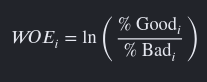  
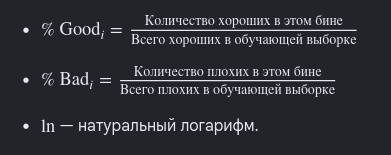  
Все сырые значения в датасете (рубли, года) перезаписываются этими коэффициентами. Пропуски (NaN) выделяются в отдельный бин со своим WoE.

### Разведовательный биннинг
На этом этапе мы создадим биннинт без монотонности или u-образности тренда для разведки. Нужно это, чтобы посмотреть закономерности между бинами, выделить их в соответсвенные группы и создать для каждого свой биннинг. Всё равно в итоге мы получим чистые значения.  
*Можно запустить и с параметром monotic_trend = auto, тогда модель будет сама определять тип закономерности, но всё равно нужно проверить в итоге будет получившийся результат, чтобы шум не ломал человеческую логику.*

In [12]:
features = list(X_train.columns)

binning_fit_params = {
    "monotonic_trend": 'none',
    "min_bin_size": 0.05,
    "dtype": 'numerical',
    "solver": 'cp'
}

binning_process = BinningProcess(
    variable_names=features,
    binning_fit_params=binning_fit_params,
    n_jobs=-1
)

binning_process.fit(X_train[features], y_train["flag"])

BinningProcess(binning_fit_params={'dtype': 'numerical', 'min_bin_size': 0.05,
                                   'monotonic_trend': 'none', 'solver': 'cp'},
               n_jobs=-1,
               variable_names=['pre_since_opened', 'pre_since_confirmed',
                               'pre_pterm', 'pre_fterm', 'pre_till_pclose',
                               'pre_till_fclose', 'pre_loans_credit_limit',
                               'pre_loans_next_pay_summ',
                               'pre_loans_outstanding',
                               'pre_loans_total_overdue',
                               'pre_lo..._overdue_sum',
                               'pre_loans_credit_cost_rate', 'pre_loans5',
                               'pre_loans530', 'pre_loans3060', 'pre_loans6090',
                               'pre_loans90', 'is_zero_loans5',
                               'is_zero_loans530', 'is_zero_loans3060',
                               'is_zero_loans6090', 'is_zero_loans90',
                               'pre_util', 'pre_over2limit',
                               'pre_maxover2limit', 'is_zero_util',
                               'is_zero_over2limit', 'is_zero_maxover2limit',
                               'enc_paym_0', 'enc_paym_1', ...])

Посмотрим как выглядит таблица для одного признака

In [13]:
target_variable = "pre_loans_credit_cost_rate"
binning_object = binning_process.get_binned_variable(name=target_variable)
detailed_table = binning_object.binning_table.build()
display(detailed_table)
del target_variable, binning_object, detailed_table
gc.collect()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 4.50)",13140917,0.669702,12725173,415744,0.031637,0.063089,0.002589,0.000324
1,"[4.50, 5.50)",1143603,0.058282,1106949,36654,0.032051,0.049662,0.000140,0.000018
2,"[5.50, 7.50)",1431402,0.072949,1350632,80770,0.056427,-0.541456,0.027710,0.003422
3,"[7.50, 10.50)",2104453,0.107249,2026268,78185,0.037152,-0.103305,0.001201,0.000150
4,"[10.50, inf)",1801662,0.091818,1753158,48504,0.026922,0.229349,0.004346,0.000542
5,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
6,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,19622037,1.000000,18962180,659857,0.033628,,0.035987,0.004455


19341

### WoE: Строим графики, сводную таблицу и анализируем
Построим графики для каждого признака. На оси x будут интервалы, на оси y будут WoE.
Наши признаки мы разобьем на 4 группы исходя из графиков:
- **Монотонные признаки:** тут мы применим режим монотонного тренда.
- **Параболические признаки:** тут мы применим режим u-образного тренда. Это мы разобьем на 2 группы (т.к. нужно указывать разные параметры в BinningProcess).
    - *Горка*: peak.
    - *Впадина*: valley.
- **Признаки со скачками либо одним и тем же значением:** эти признаки мы просто не будем учитывать в модели.

,pre_since_opened,pre_since_confirmed,pre_pterm,pre_fterm,pre_till_pclose,pre_till_fclose,pre_loans_credit_limit,pre_loans_next_pay_summ,pre_loans_outstanding,pre_loans_total_overdue,pre_loans_max_overdue_sum,pre_loans_credit_cost_rate,pre_loans5,pre_loans530,pre_loans3060,pre_loans6090,pre_loans90,is_zero_loans5,is_zero_loans530,is_zero_loans3060,is_zero_loans6090,is_zero_loans90,pre_util,pre_over2limit,pre_maxover2limit,is_zero_util,is_zero_over2limit,is_zero_maxover2limit,enc_paym_0,enc_paym_1,enc_paym_2,enc_paym_3,enc_paym_4,enc_paym_5,enc_paym_6,enc_paym_7,enc_paym_8,enc_paym_9,enc_paym_10,enc_paym_11,enc_paym_12,enc_paym_13,enc_paym_14,enc_paym_15,enc_paym_16,enc_paym_17,enc_paym_18,enc_paym_19,enc_paym_20,enc_paym_21,enc_paym_22,enc_paym_23,enc_paym_24,enc_loans_account_holder_type,enc_loans_credit_status,enc_loans_credit_type,enc_loans_account_cur,pclose_flag,fclose_flag
0,-0.032771,-0.115374,-0.103346,-0.062343,-0.017527,0.007891,0.077483,0.023797,-0.077737,0.0,0.0,0.063089,0.0,0.0,0.0,0.0,0.0,-0.23017,-0.277037,0.0,0.0,0.0,-0.271567,0.003051,-0.181411,-0.117557,-0.087333,-0.176392,0.053114,0.110381,0.135279,0.144761,0.149871,0.153263,0.156279,0.163743,0.1671,0.172303,0.174344,0.181444,0.190107,0.206033,0.215521,0.223052,0.229496,0.233133,0.2388,0.244371,0.244142,0.244951,0.244552,0.244273,0.220849,0.0,-0.076672,0.36412,0.0,0.002145,0.02293
1,0.168743,-0.029407,0.275067,0.058685,0.107251,0.144321,0.491455,-0.002228,0.041018,NaN,NaN,0.049662,NaN,NaN,NaN,NaN,NaN,0.022955,0.065622,NaN,NaN,NaN,-0.013044,-0.041508,0.022493,0.055185,0.006856,0.032839,-0.48871,-0.373665,-0.373232,-0.383904,-0.293811,-0.252113,-0.209814,-0.181024,-0.161132,-0.145535,-0.126247,-0.111304,-0.097659,-0.088609,-0.084188,-0.080681,-0.077292,-0.073404,-0.069736,-0.066494,-0.062577,-0.05926,-0.055833,-0.052308,-0.03459,NaN,0.03776,0.028053,NaN,-0.012146,-0.073797
2,0.20847,-0.012119,0.084288,0.127726,0.161825,-0.013779,0.000072,-0.051571,-0.218058,NaN,NaN,-0.541456,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.045159,NaN,NaN,NaN,NaN,NaN,NaN,-0.453902,-0.405063,-0.332466,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.680063,NaN,NaN,NaN
3,0.103666,0.172139,0.060515,0.090904,-0.036169,-0.120929,-0.263911,-0.075072,NaN,NaN,NaN,-0.103305,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,-0.144252,0.039565,0.059085,0.086853,NaN,NaN,NaN,0.070674,NaN,NaN,NaN,0.229349,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


0

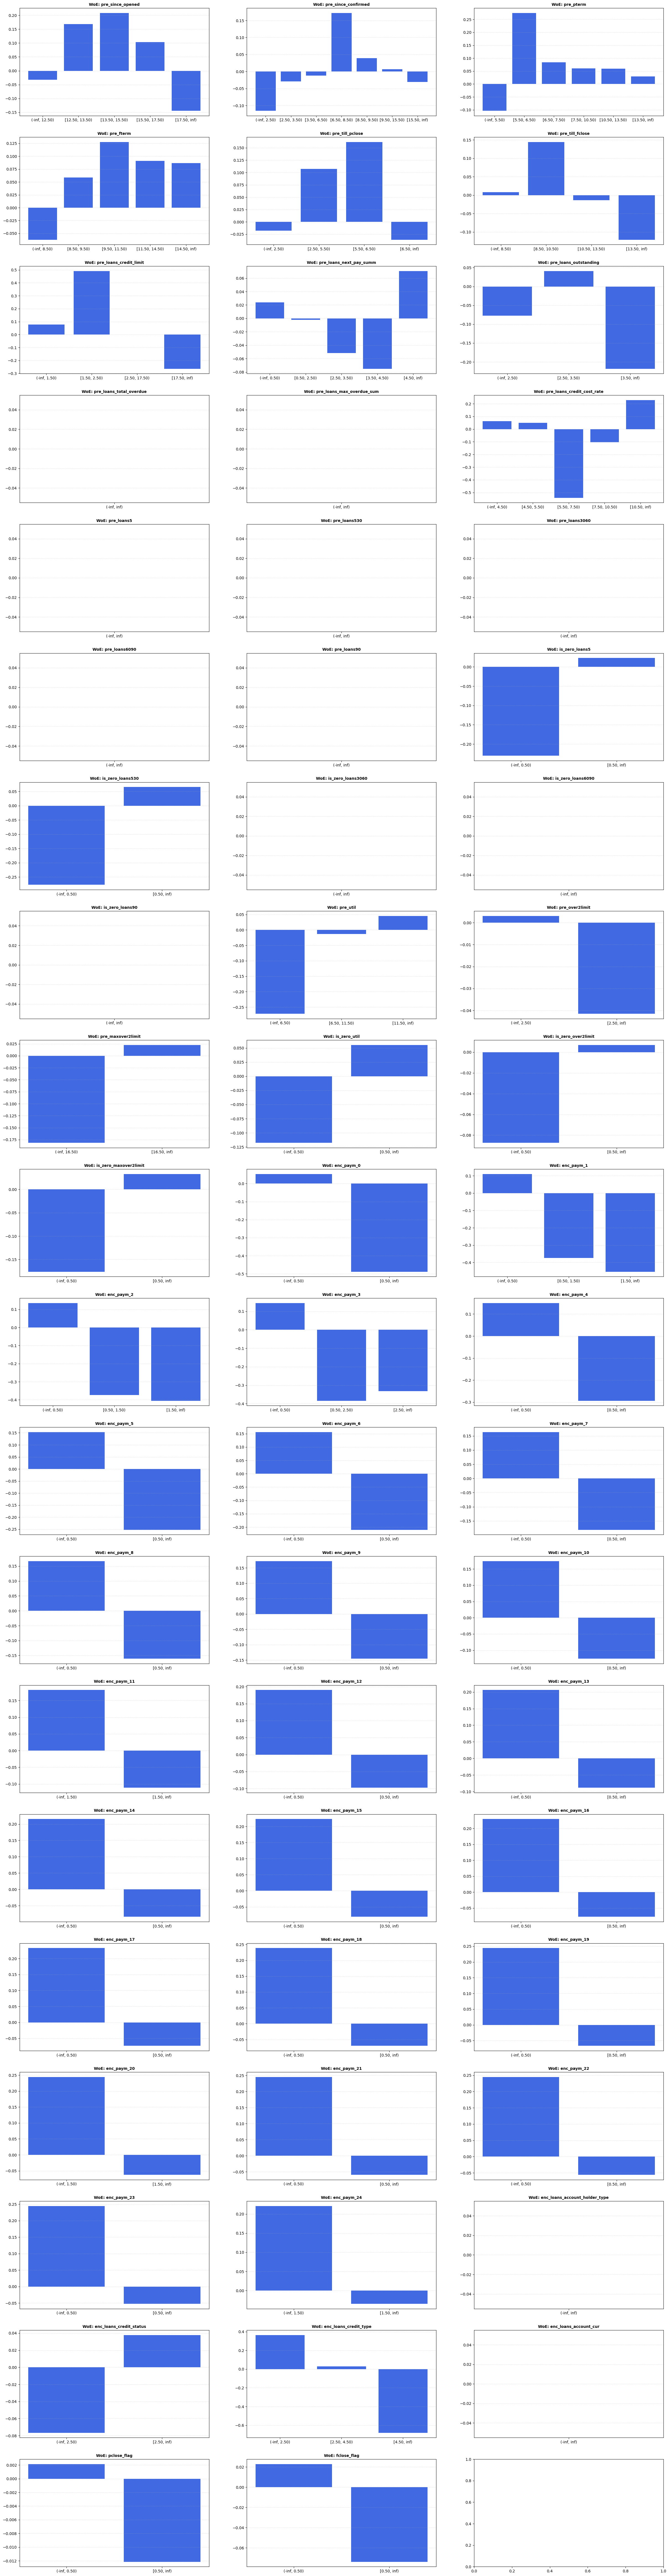

In [14]:
df_woe = pd.DataFrame(columns=features)
fig, axes = plt.subplots(nrows=20, ncols=3, figsize=(30,120))
axes = axes.flatten()

for ax, feature in zip(axes, features):
    binning_object = binning_process.get_binned_variable(name=feature)
    detailed_table = binning_object.binning_table.build()
    df_clean = detailed_table[~detailed_table['Bin'].isin(['Totals', 'Missing', 'Special'])].copy().iloc[:-1] #удаляем служебные и последнюю строку
    df_woe[feature] = df_clean['WoE']
    x = df_clean['Bin'].astype(str).values
    y = df_clean['WoE']
    ax.bar(x, y, color='royalblue')
    ax.set_title(f"WoE: {feature}", fontsize=10, fontweight='bold')
    ax.grid(axis='y', linestyle=':', alpha=0.6)
    del x, y, df_clean, binning_object, detailed_table
    gc.collect()
with pd.option_context('display.max_columns', None): # Чтобы отобразить весь датафрейм
    display(df_woe)
del binning_process
gc.collect()

Выделяем всё в отдельные  группы теперь и строим биннинги.

In [15]:
peak_features = ['pre_since_opened', 'pre_since_confirmed', 'pre_pterm', 'pre_fterm', 'pre_till_pclose', 'pre_till_fclose', 'pre_loans_credit_limit', 'pre_loans_outstanding', 'enc_paym_3']
valley_features = ['pre_loans_next_pay_summ', 'pre_loans_credit_cost_rate']
useless_features = ['pre_loans_total_overdue', 'pre_loans_max_overdue_sum', 'pre_loans5', 'pre_loans530', 'pre_loans3060', 'pre_loans6090', 'pre_loans90', 'is_zero_loans3060', 'is_zero_loans6090', 'is_zero_loans90', 'enc_loans_account_holder_type', 'enc_loans_account_cur']
monotonitc_features = [feature for feature in features if (feature not in peak_features) and (feature not in valley_features) and (feature not in useless_features)]
usefull_features = list(peak_features) + list(valley_features) + list(monotonitc_features)
del useless_features
gc.collect()

10484

In [16]:
custom_binning_fit_params = {}

for col in peak_features:
    custom_binning_fit_params[col] = {"monotonic_trend": 'peak'}

for col in valley_features:
    custom_binning_fit_params[col] = {"monotonic_trend": 'valley'}

for col in monotonitc_features:
    custom_binning_fit_params[col] = {"monotonic_trend": 'auto_asc_desc'}

for col in usefull_features:
    custom_binning_fit_params[col]["min_bin_size"] = 0.05
    custom_binning_fit_params[col]["dtype"] = "numerical"
    custom_binning_fit_params[col]["solver"] = "cp"

filtered_binning_process = BinningProcess(
    variable_names=usefull_features,
    binning_fit_params=custom_binning_fit_params,
    n_jobs=-1
)

filtered_binning_process.fit(X_train[usefull_features], y_train["flag"])

del peak_features, valley_features, monotonitc_features
gc.collect()

19225

In [17]:
X_train_woe_filtered = filtered_binning_process.transform(X_train[usefull_features], metric="woe")

### WoE: Итоговые преобразованные тренировочные данные

In [18]:
display(X_train_woe_filtered)

,pre_since_opened,pre_since_confirmed,pre_pterm,pre_fterm,pre_till_pclose,pre_till_fclose,pre_loans_credit_limit,pre_loans_outstanding,enc_paym_3,pre_loans_next_pay_summ,pre_loans_credit_cost_rate,is_zero_loans5,is_zero_loans530,pre_util,pre_over2limit,pre_maxover2limit,is_zero_util,is_zero_over2limit,is_zero_maxover2limit,enc_paym_0,enc_paym_1,enc_paym_2,enc_paym_4,enc_paym_5,enc_paym_6,enc_paym_7,enc_paym_8,enc_paym_9,enc_paym_10,enc_paym_11,enc_paym_12,enc_paym_13,enc_paym_14,enc_paym_15,enc_paym_16,enc_paym_17,enc_paym_18,enc_paym_19,enc_paym_20,enc_paym_21,enc_paym_22,enc_paym_23,enc_paym_24,enc_loans_credit_status,enc_loans_credit_type,pclose_flag,fclose_flag
24340877,0.063440,0.033886,-0.237192,-0.074148,0.039208,0.122491,0.197640,0.026944,-0.332466,-0.022086,0.011870,0.022955,0.065622,0.045159,0.003051,0.022493,0.055185,0.006856,0.032839,-0.488710,-0.453902,-0.405063,-0.293811,-0.252113,-0.209814,-0.181024,-0.161132,-0.145535,-0.126247,-0.111304,-0.097659,-0.088609,-0.084188,-0.080681,-0.077292,-0.073404,-0.069736,-0.066494,-0.062577,-0.059260,-0.055833,-0.052308,-0.03459,0.037760,0.028053,-0.012146,0.022930
21891453,0.063440,0.033886,0.059042,-0.074148,-0.049922,0.122491,0.000072,0.026944,0.144761,-0.006128,-0.005646,0.022955,0.065622,0.045159,0.003051,0.022493,0.055185,0.006856,0.032839,0.053114,0.110381,0.135279,0.149871,-0.252113,-0.209814,-0.181024,-0.161132,-0.145535,-0.126247,-0.111304,-0.097659,-0.088609,-0.084188,-0.080681,-0.077292,-0.073404,-0.069736,-0.066494,-0.062577,-0.059260,-0.055833,-0.052308,-0.03459,0.037760,0.028053,0.002145,0.022930
13860272,0.008198,0.033886,0.059042,-0.074148,0.039208,0.012745,0.000072,0.026944,-0.332466,-0.022086,-0.041656,0.022955,0.065622,0.045159,0.003051,0.022493,0.055185,0.006856,0.032839,0.053114,-0.453902,-0.405063,-0.293811,-0.252113,-0.209814,-0.181024,-0.161132,-0.145535,-0.126247,-0.111304,-0.097659,-0.088609,-0.084188,-0.080681,-0.077292,-0.073404,-0.069736,-0.066494,-0.062577,-0.059260,-0.055833,-0.052308,-0.03459,0.037760,0.028053,0.002145,0.022930
10181192,0.008198,-0.012119,0.059042,0.094855,-0.049922,-0.120929,0.000072,0.026944,0.144761,-0.006128,0.186343,0.022955,0.065622,-0.013044,0.003051,0.022493,-0.117557,0.006856,0.032839,0.053114,0.110381,0.135279,0.149871,0.153263,0.156279,0.163743,0.167100,0.172303,0.174344,0.181444,0.190107,0.206033,0.215521,0.223052,0.229496,0.233133,0.238800,0.244371,0.244142,0.244951,-0.055833,-0.052308,-0.03459,0.037760,0.364120,0.002145,0.022930
17088102,0.063440,0.033886,0.059042,-0.074148,0.039208,0.012745,-0.263911,0.026944,0.144761,-0.006128,0.186343,0.022955,0.065622,0.045159,0.003051,0.022493,0.055185,0.006856,0.032839,-0.488710,0.110381,0.135279,0.149871,0.153263,0.156279,-0.181024,-0.161132,-0.145535,-0.126247,-0.111304,-0.097659,-0.088609,-0.084188,-0.080681,-0.077292,-0.073404,-0.069736,-0.066494,-0.062577,-0.059260,-0.055833,-0.052308,-0.03459,0.037760,0.028053,0.002145,0.022930
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1793628,0.008198,-0.115374,0.059042,-0.074148,0.039208,-0.013779,0.000072,0.026944,0.144761,-0.006128,0.186343,0.022955,0.065622,-0.013044,0.003051,0.022493,-0.117557,0.006856,0.032839,0.053114,0.110381,0.135279,0.149871,0.153263,0.156279,-0.181024,-0.161132,-0.145535,-0.126247,-0.111304,-0.097659,-0.088609,-0.084188,-0.080681,-0.077292,-0.073404,-0.069736,-0.066494,-0.062577,-0.059260,-0.055833,-0.052308,-0.03459,-0.076672,0.028053,0.002145,-0.073797
3393336,-0.003492,0.033886,0.059042,-0.074148,0.041617,-0.013779,0.197640,0.026944,0.144761,-0.006128,-0.005646,0.022955,0.065622,0.045159,0.003051,0.022493,0.055185,0.006856,0.032839,0.053114,0.110381,0.135279,0.149871,0.153263,-0.209814,-0.181024,-0.161132,-0.145535,-0.126247,-0.111304,-0.097659,-0.088609,-0.084188,-0.080681,-0.077292,-0.073404,-0.069736,-0.066494,-0.062577,-0.059260,-0.055833,-0.052308,-0.

## 3. Отбор признаков (IV, VIF)
Выведем таблицу с характеристикой признаков

In [19]:
df_summary = filtered_binning_process.summary()
display(df_summary)

,name,dtype,status,selected,n_bins,iv,js,gini,quality_score
0,pre_since_opened,numerical,OPTIMAL,True,5,0.014208,0.001769,0.050167,0.047591
1,pre_since_confirmed,numerical,OPTIMAL,True,4,0.002758,0.000345,0.024532,0.007586
2,pre_pterm,numerical,OPTIMAL,True,4,0.017193,0.002145,0.060075,0.051622
3,pre_fterm,numerical,OPTIMAL,True,7,0.014905,0.00186,0.062715,0.051977
4,pre_till_pclose,numerical,OPTIMAL,True,5,0.007222,0.0009,0.031215,0.023327
5,pre_till_fclose,numerical,OPTIMAL,True,4,0.002986,0.000373,0.025427,0.009749
6,pre_loans_credit_limit,numerical,OPTIMAL,True,3,0.01313,0.001637,0.049699,0.027865
7,pre_loans_outstanding,numerical,OPTIMAL,True,2,0.005872,0.000733,0.023969,0.005828
8,enc_paym_3,numerical,OPTIMAL,True,3,0.049667,0.006185,0.102182,0.101837
9,pre_loans_next_pay_summ,numerical,OPTIMAL,True,4,0.003526,0.00044,0.017488,0.006439


### Фильтрация по силе признака (Information Value — IV).
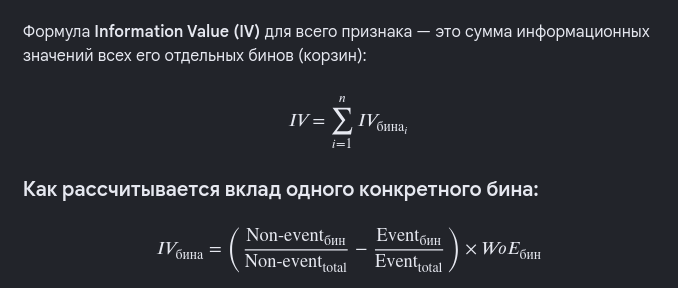  
Для каждого фактора рассчитывается суммарный IV.  
- Признаки с \(IV < 0.02\) (мусорные) — удаляются.
- Признаки с \(IV > 0.5\) проверяются на Data Leakage (утечку ответов из будущего) и чаще всего удаляются.
- В работу уходят факторы со средней и высокой силой (\(0.1 \le IV < 0.5\)).

In [20]:
df_summary_filtered_by_iv = df_summary[df_summary['iv'] > 0.02]
display(df_summary_filtered_by_iv)
iv_filtered_features = df_summary_filtered_by_iv['name']
X_train_iv_filtered = X_train_woe_filtered[iv_filtered_features]

,name,dtype,status,selected,n_bins,iv,js,gini,quality_score
8,enc_paym_3,numerical,OPTIMAL,True,3,0.049667,0.006185,0.102182,0.101837
19,enc_paym_0,numerical,OPTIMAL,True,2,0.025902,0.003209,0.047804,0.02052
20,enc_paym_1,numerical,OPTIMAL,True,3,0.047209,0.005864,0.088094,0.071041
21,enc_paym_2,numerical,OPTIMAL,True,3,0.053547,0.006659,0.100837,0.096005
22,enc_paym_4,numerical,OPTIMAL,True,2,0.043873,0.005469,0.098884,0.100323
23,enc_paym_5,numerical,OPTIMAL,True,2,0.038516,0.004805,0.095012,0.094812
24,enc_paym_6,numerical,OPTIMAL,True,2,0.0327,0.004081,0.089322,0.085778
25,enc_paym_7,numerical,OPTIMAL,True,2,0.029568,0.003691,0.085763,0.080515
26,enc_paym_8,numerical,OPTIMAL,True,2,0.026865,0.003354,0.081847,0.074192
27,enc_paym_9,numerical,OPTIMAL,True,2,0.025024,0.003125,0.078732,0.069356


### Проверка на мультиколлинеарность:
- Строится матрицу корреляции WOE-переменных. Если парная корреляция между факторами \(> 0.5–0.6\), оставляют один признак с наибольшим IV.
- Рассчитывается фактор инфляции дисперсии (VIF). Он должен быть строго \(<5\).  
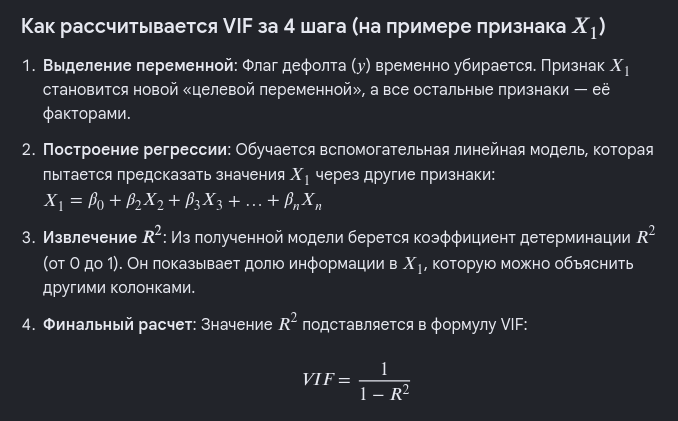  
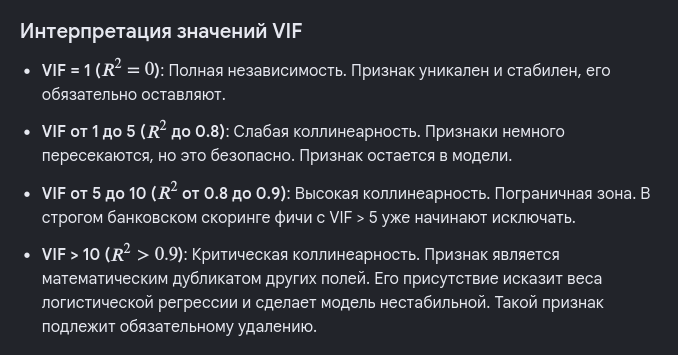

In [21]:
vif_threshold = 5.0
X_sample = X_train_iv_filtered.sample(n=2500000, random_state=42).copy()
X_sample['intercept'] = 1.0
dropped_features = []
while True:
    columns = [c for c in X_sample.columns if c != 'intercept']
    if len(columns) == 0:
        break
    data_matrix = X_sample.values.astype(np.float64)
    vifs = [variance_inflation_factor(data_matrix, i) for i in range(data_matrix.shape[1])]
    df_vif = pd.DataFrame({'feature': X_sample.columns, 'vif': vifs})
    df_vif = df_vif[df_vif['feature'] != 'intercept']
    max_vif_row = df_vif.loc[df_vif['vif'].idxmax()]
    if(max_vif_row['vif'] < vif_threshold):
        break
    else:
        feature_to_drop = max_vif_row['feature']
        print(f" -> Удален дубликат: {feature_to_drop:<30} | Его VIF на шаге = {max_vif_row['vif']:.2f}")
        dropped_features.append(feature_to_drop)
        X_sample.drop(columns=[feature_to_drop], inplace=True)
        
final_features = [c for c in iv_filtered_features if c not in dropped_features]

X_final_for_log_reg = X_train_iv_filtered[final_features]
display(X_final_for_log_reg)

 -> Удален дубликат: enc_paym_9                     | Его VIF на шаге = 5.67


,enc_paym_3,enc_paym_0,enc_paym_1,enc_paym_2,enc_paym_4,enc_paym_5,enc_paym_6,enc_paym_7,enc_paym_8,enc_paym_10,enc_paym_11,enc_loans_credit_type
24340877,-0.332466,-0.488710,-0.453902,-0.405063,-0.293811,-0.252113,-0.209814,-0.181024,-0.161132,-0.126247,-0.111304,0.028053
21891453,0.144761,0.053114,0.110381,0.135279,0.149871,-0.252113,-0.209814,-0.181024,-0.161132,-0.126247,-0.111304,0.028053
13860272,-0.332466,0.053114,-0.453902,-0.405063,-0.293811,-0.252113,-0.209814,-0.181024,-0.161132,-0.126247,-0.111304,0.028053
10181192,0.144761,0.053114,0.110381,0.135279,0.149871,0.153263,0.156279,0.163743,0.167100,0.174344,0.181444,0.364120
17088102,0.144761,-0.488710,0.110381,0.135279,0.149871,0.153263,0.156279,-0.181024,-0.161132,-0.126247,-0.111304,0.028053
...,...,...,...,...,...,...,...,...,...,...,...,...
1793628,0.144761,0.053114,0.110381,0.135279,0.149871,0.153263,0.156279,-0.181024,-0.161132,-0.126247,-0.111304,0.028053
3393336,0.144761,0.053114,0.110381,0.135279,0.149871,0.153263,-0.209814,-0.181024,-0.161132,-0.126247,-0.111304,0.028053
13545144,0.144761,0.053114,0.110381,0.135279,0.149871,0.153263,0.156279,0.163743,0.167100,0.174344,0.181444,0.028053
20971060,0.144761,0.053114,0.110381,0.135279,0.149871,0.153263,-0.209814,-0.181024,-0.161132,-0.126247,-0.111304,0.028053


## 4. Обучение логистической регресии
На вход подаются оставшиеся 8–15 «чистых» WOE-признаков. Алгоритм находит веса (\(\beta \)) для уравнения логарифма шансов дефолта. Все \(\beta \) обязаны получиться положительными.  
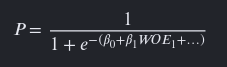  
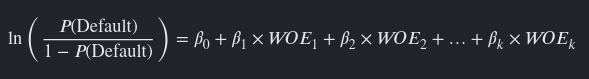

In [23]:
log_reg = LogisticRegression(n_jobs=-1, class_weight='balanced', random_state=42, max_iter=500)
log_reg.fit(X_final_for_log_reg, y_train['flag'])

LogisticRegression(class_weight='balanced', max_iter=500, n_jobs=-1,
                   random_state=42)

In [ ]:
X_val_woe = filtered_binning_process.transform(X_val[usefull_features], metric="woe")
X_val_cutted = X_val_woe[final_features]

'              precision    recall  f1-score   support\n\n           0       0.97      0.71      0.82   6320728\n           1       0.05      0.41      0.08    219952\n\n    accuracy                           0.70   6540680\n   macro avg       0.51      0.56      0.45   6540680\nweighted avg       0.94      0.70      0.80   6540680\n'

In [28]:
y_pred = log_reg.predict(X_val_cutted)
print(classification_report(y_val, y_pred))
print(f"Roc Auc: {roc_auc_score(y_val, y_pred)}")

              precision    recall  f1-score   support

           0       0.97      0.71      0.82   6320728
           1       0.05      0.41      0.08    219952

    accuracy                           0.70   6540680
   macro avg       0.51      0.56      0.45   6540680
weighted avg       0.94      0.70      0.80   6540680

Roc Auc: 0.5595550494765368


In [23]:
#X_test_filtered = X_test[final_features]
#for feature in final_features:
#    binned_feature = filtered_binning_process.get_binned_variable(name=feature)
#    X_test_filtered[feature] = binned_feature.transform(X_test_filtered[feature], metric="woe")

## 5. Скейлинг (Создание скоринговой карты)
Превращение формулы регрессии в понятную человеку таблицу баллов.
- **Фиксация бизнес-констант:** Бизнес задает три параметра:
    - Base Score (например, 600 баллов).
    - Base Odds (например, шансы 50:1, что соответствует среднему риску портфеля).
    - PDO (шаг удваивания шансов, например, 20 баллов).  
- **Пересчет весов:** С помощью математических коэффициентов (*Factor* и *Offset*) веса регрессии \(\beta \) и значения \(WOE\) каждого бина пересчитываются в целые числа — баллы.  
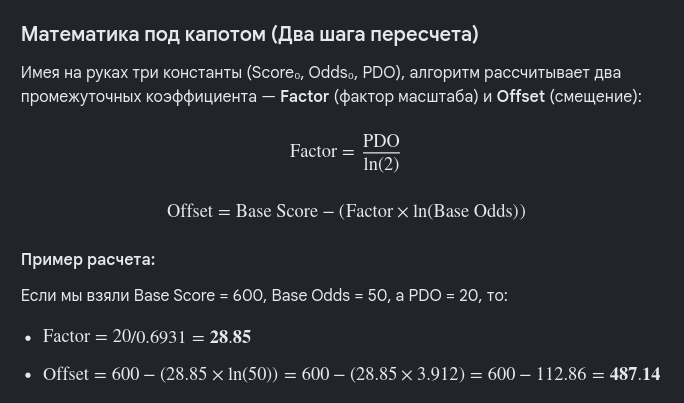  
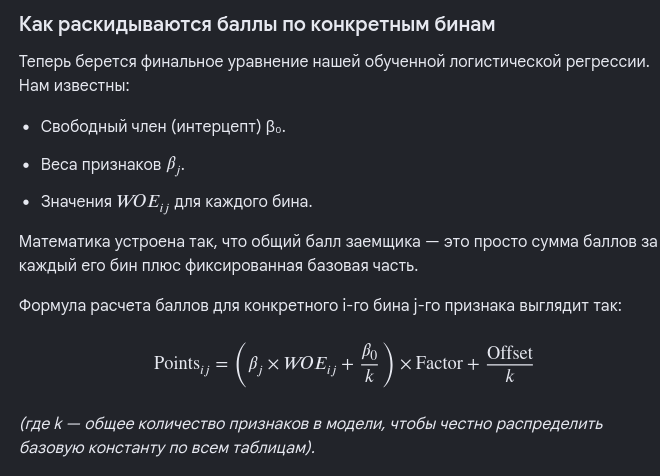  
- **Формирование Scorecard:** На выходе получается итоговая таблица (карта), где за каждый интервал дохода или возраста клиенту положен фиксированный балл (например: Возраст 25–35 лет \(\rightarrow \) +45 баллов). Общий сколл-балл — это простая сумма баллов по всем факторам.  
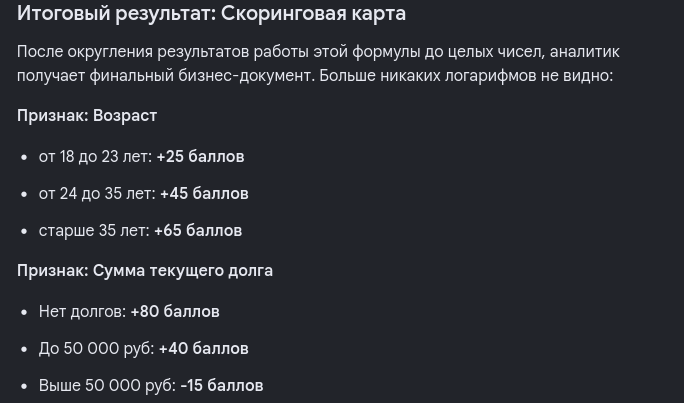  

## 6. Обучение CatBoost
Теперь обучим бустинг. Преимущество его в том, что нам не нужно делать биннинг для его обучения.

In [24]:
true_features = [col for col in X_train.columns if col not in ['id', 'rn']]

X_sample = X_train[true_features].sample(n=1000000, random_state=42).astype(np.float32)
y_sample = y_train["flag"].sample(n=1000000, random_state=42).values

cat_base = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    metric_period=10,
    auto_class_weights='Balanced',
    task_type="GPU",
    random_seed=42,
    verbose=False
)

param_distribution = {
    'iterations': randint(150, 600),
    'learning_rate': uniform(0.02, 0.1),
    'depth':randint(4, 9),
    'l2_leaf_reg':randint(1, 12),
    'bootstrap_type': ['Bernoulli'],
    'subsample': uniform(0.7, 0.3)
}

search_results = cat_base.randomized_search(
    param_distributions=param_distribution,
    X=X_sample,
    y=y_sample,
    cv=3,
    n_iter=60,                                 
    partition_random_seed=42,
    plot=False
)

best_params = search_results['params']
print("Лучшие настройки для модели:")
for param, value in best_params.items():
    print(f" -> {param}: {value}")

del X_sample, y_sample
gc.collect()

bestTest = 0.6369068623
bestIteration = 224
Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.
0:	loss: 0.6369069	best: 0.6369069 (0)	total: 6.45s	remaining: 6m 20s
bestTest = 0.6378092766
bestIteration = 296
Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.
1:	loss: 0.6378093	best: 0.6378093 (1)	total: 17.1s	remaining: 8m 17s
bestTest = 0.6342206001
bestIteration = 342
Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.
2:	loss: 0.6342206	best: 0.6378093 (1)	total: 24.1s	remaining: 7m 37s
bestTest = 0.6378332078
bestIteration = 250
Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.
3:	loss: 0.6378332	best: 0.6378332 (3)	total: 34.3s	remaining: 8m
bestTest = 0

32

In [25]:
cv_pool = Pool(
    data=X_train[true_features].astype(np.float32), 
    label=y_train['flag'].values
)

cat_cv_params = {
    "loss_function": "Logloss",
    "eval_metric": "AUC",
    "metric_period": 10,
    "auto_class_weights": "Balanced",
    "task_type": "GPU",
    "random_seed": 42,
    "verbose": 50
}

cat_cv_params.update(best_params)

cv_results = cv(
    pool=cv_pool,
    params=cat_cv_params,
    fold_count=5,
    partition_random_seed=42,
    plot=False
)

best_iteration = cv_results['test-AUC-mean'].idxmax()
mean_auc = cv_results['test-AUC-mean'].max()
std_auc = cv_results['test-AUC-std'].iloc[best_iteration]

mean_gini = 2 * mean_auc - 1

print(f"Лучшая итерация (дерево):{best_iteration}")
print(f"Средний ROC-AUC на валидации:{mean_auc:.4f}")
print(f"Разброс ROC-AUC (Std):{std_auc:.4f}")
print(f"GINI:{mean_gini:.4f}")

Training on fold [0/5]
0:	test: 0.6009669	best: 0.6009669 (0)	total: 2.57s	remaining: 18m 29s
50:	test: 0.6315084	best: 0.6315084 (50)	total: 2m 8s	remaining: 16m
100:	test: 0.6381361	best: 0.6381361 (100)	total: 3m 1s	remaining: 9m 54s
150:	test: 0.6412474	best: 0.6412474 (150)	total: 3m 23s	remaining: 6m 17s
200:	test: 0.6428098	best: 0.6428098 (200)	total: 3m 41s	remaining: 4m 14s
250:	test: 0.6438093	best: 0.6438093 (250)	total: 3m 58s	remaining: 2m 51s
300:	test: 0.6442398	best: 0.6442398 (300)	total: 4m 12s	remaining: 1m 49s
350:	test: 0.6448971	best: 0.6448971 (350)	total: 4m 30s	remaining: 1m 2s
400:	test: 0.6453904	best: 0.6453904 (400)	total: 4m 46s	remaining: 22.1s
431:	test: 0.6455268	best: 0.6455268 (431)	total: 4m 55s	remaining: 0us
bestTest = 0.6455267668
bestIteration = 431
Training on fold [1/5]
0:	test: 0.6020979	best: 0.6020979 (0)	total: 577ms	remaining: 4m 8s
50:	test: 0.6325673	best: 0.6325673 (50)	total: 23.2s	remaining: 2m 52s
100:	test: 0.6388252	best: 0.638825